**Factors Influencing Students Academic Performance**

**Autor**: João Pedro Freire Barroso Magalhaes

**Data**: 19/02/2025

**Dataset**: [Students Performance | Clean Dataset](http://www.kaggle.com/datasets/muhammadroshaanriaz/students-performance-dataset-cleaned/data)





**Introduction**:
A educação é um dos pilares fundamentais para o desenvolvimento individual e social. Compreender os fatores que influenciam o desempenho acadêmico dos alunos pode ajudar na criação de políticas educacionais mais eficazes e no desenvolvimento de estratégias para melhorar a aprendizagem.Neste projeto, analisamos um conjunto de dados contendo informações sobre estudantes e seus desempenhos em três disciplinas: matemática, leitura e escrita. Além das notas, o dataset inclui variáveis como gênero, nível de escolaridade dos pais, tipo de almoço e participação em cursos preparatórios.Nosso objetivo é explorar como diferentes fatores podem impactar o desempenho dos alunos e identificar padrões que possam fornecer insights valiosos para educadores e gestores da área.




In [1]:
# Importação das Bibliotecas

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Carregando o Dataset

df = pd.read_csv('/kaggle/input/students-performance-dataset-cleaned/Cleaned_Students_Performance.csv')

In [3]:
# Explorando o Dataset

df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,0,group B,bachelor's degree,1,0,72,72,74,218,72.666667
1,0,group C,some college,1,1,69,90,88,247,82.333333
2,0,group B,master's degree,1,0,90,95,93,278,92.666667
3,1,group A,associate's degree,0,0,47,57,44,148,49.333333
4,1,group C,some college,1,0,76,78,75,229,76.333333


In [4]:
# Informações do Dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   int64  
 1   race_ethnicity               1000 non-null   object 
 2   parental_level_of_education  1000 non-null   object 
 3   lunch                        1000 non-null   int64  
 4   test_preparation_course      1000 non-null   int64  
 5   math_score                   1000 non-null   int64  
 6   reading_score                1000 non-null   int64  
 7   writing_score                1000 non-null   int64  
 8   total_score                  1000 non-null   int64  
 9   average_score                1000 non-null   float64
dtypes: float64(1), int64(7), object(2)
memory usage: 78.2+ KB


In [5]:
# Visualização de estatísticas do Dataset

df.describe()

,gender,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.482000,0.645000,0.358000,66.08900,69.169000,68.054000,203.312000,67.770667
std,0.499926,0.478753,0.479652,15.16308,14.600192,15.195657,42.771978,14.257326
min,0.000000,0.000000,0.000000,0.00000,17.000000,10.000000,27.000000,9.000000
25%,0.000000,0.000000,0.000000,57.00000,59.000000,57.750000,175.000000,58.333333
50%,0.000000,1.000000,0.000000,66.00000,70.000000,69.000000,205.000000,68.333333
75%,1.000000,1.000000,1.000000,77.00000,79.000000,79.000000,233.000000,77.666667
max,1.000000,1.000000,1.000000,100.00000,100.000000,100.000000,300.000000,100.000000


In [6]:
#Verificar colunas
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'total_score', 'average_score'],
      dtype='object')

<Figure size 800x600 with 0 Axes>

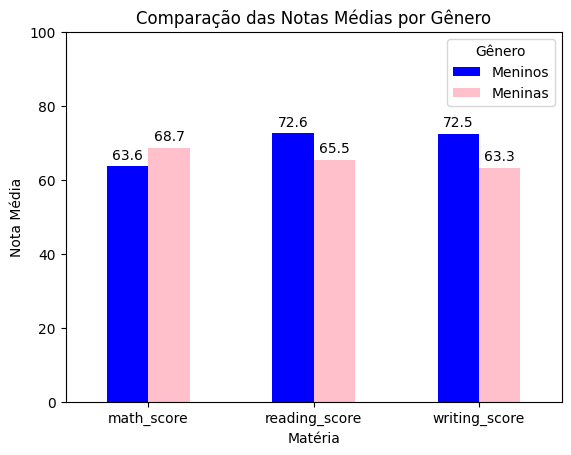

In [7]:
# Agrupando as médias das notas por gênero
mean_scores = df.groupby("gender")[["math_score", "reading_score", "writing_score"]].mean()

# Criando o gráfico de barras
plt.figure(figsize=(8, 6))
ax = mean_scores.T.plot(kind="bar", color=["blue", "pink"])

# Adicionando os valores exatos no topo de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

# Ajustando rótulos e título
plt.title("Comparação das Notas Médias por Gênero")
plt.xlabel("Matéria")
plt.ylabel("Nota Média")
plt.xticks(rotation=0)
plt.legend(["Meninos", "Meninas"], title="Gênero")
plt.ylim(0, 100)

# Exibindo o gráfico
plt.show()


<Figure size 800x600 with 0 Axes>

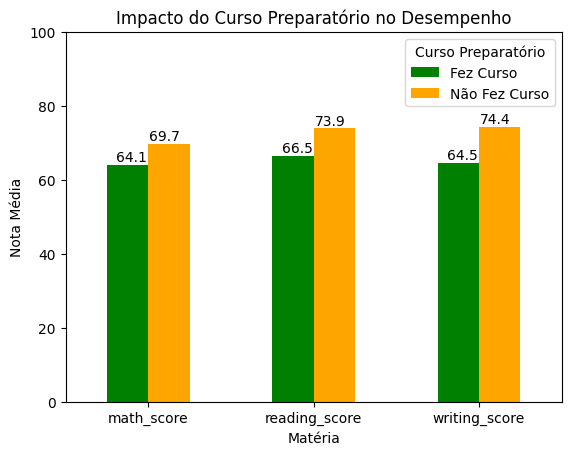

In [8]:
# Agrupando as notas médias por participação no curso preparatório
prep_scores = df.groupby("test_preparation_course")[["math_score", "reading_score", "writing_score"]].mean()

# Criando o gráfico de barras
plt.figure(figsize=(8, 6))
prep_scores.T.plot(kind="bar", color=["green", "orange"])  # Verde para "completed", laranja para "none"
plt.title("Impacto do Curso Preparatório no Desempenho")
plt.xlabel("Matéria")
plt.ylabel("Nota Média")
plt.xticks(rotation=0)
plt.legend(["Fez Curso", "Não Fez Curso"], title="Curso Preparatório")
plt.ylim(0, 100)

for i, subject in enumerate(prep_scores.columns):
    for j, value in enumerate(prep_scores.loc[:, subject]):
        plt.text(i + j * 0.2 - 0.1, value + 1, f"{value:.1f}", ha="center", fontsize=10)

plt.show()


In [9]:
df["parental_level_of_education"].unique()


array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

<Figure size 1000x600 with 0 Axes>

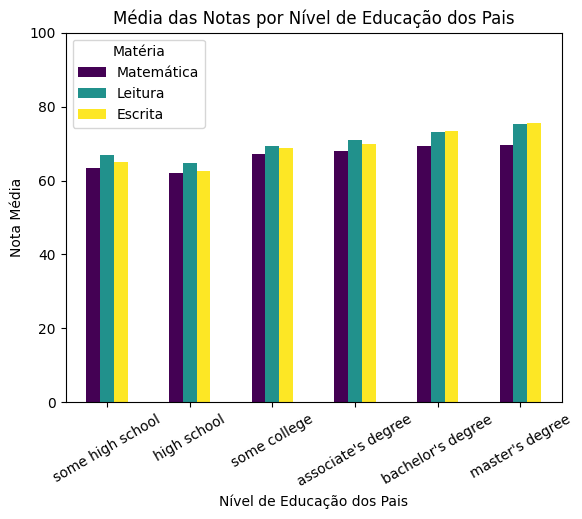

In [10]:
# Calculando a média das notas por nível de educação dos pais
education_scores = df.groupby("parental_level_of_education")[["math_score", "reading_score", "writing_score"]].mean()

# Ordenando pelo nível educacional (do menor para o maior)
education_scores = education_scores.reindex(['some high school', 'high school', 'some college', "associate's degree", "bachelor's degree", "master's degree"])

# Criando o gráfico de barras
plt.figure(figsize=(10, 6))
education_scores.plot(kind="bar", colormap="viridis")
plt.title("Média das Notas por Nível de Educação dos Pais")
plt.xlabel("Nível de Educação dos Pais")
plt.ylabel("Nota Média")
plt.xticks(rotation=30)  
plt.ylim(0, 100)  # Ajustando a escala das notas
plt.legend(["Matemática", "Leitura", "Escrita"], title="Matéria")
plt.show()
